In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import time

import torch
import numpy as np

from matplotlib import pyplot as plt

import kind
import utils_plot
import utils_data

In [2]:
def plot_modes(model, datadir, timeseries_nsample, jtimeseries):
    """
    Displays the amplitudes of a ``model`` eigenvalues for data from ``datadir`` indexed by
    ``jtimeseries``. Parameter ``timeseries_nsample`` is needed to read ``datadir``
    and extract proper timeseries. The displayed amplitudes are aligned
    with the corresponding ``model`` predictions.
    """

    # --! extract eigenvalues and eigenvectors from a stationary DMD-like operator
    eigval, eigvec        = torch.linalg.eig(model.operator_stat.mod_mean.weight)
    testdata              = utils_data.read_datafile(f'{datadir}/eval', timeseries_nsample)
    lookback_nsample      = model.lookback_nsample
    timeseries_ndim       = model.timeseries_ndim

    testdata = utils_data.scale_timeseries2(utils_data.remove_mean2(testdata[jtimeseries]))

    # --! take the initial condition of timeseries specified by index j and
    # --! embed this initial condition into the latent space
    # --! of the stationary model
    data_ic     = torch.unsqueeze(testdata[:model.operator_stat.param_kernsize, :], 0)
    fun_ic      = model.operator_stat.embed(data_ic)

    # --! now multiply eigenvectors and initial conditions together in a dot product fashion to
    # --! find out how aligned these two are, and thus we get our modal amplitude,
    # --! where a greater modal amplitude means more 'involvement' of a
    # --! particular eigenvalue in modeling the evolution of
    # --! particular time series.
    #
    # --! under the hood, the eignevectors must be inverted to achieve proper projection
    # --! of the initial condition into the eigen basis
    eigvec_inv  = torch.linalg.inv(eigvec)
    fun_ic      = torch.squeeze(fun_ic, 0)
    eigvec_inv  = torch.squeeze(eigvec_inv, 0)
    fun_ic      = fun_ic.to(torch.cfloat)
    amp         = torch.matmul(eigvec_inv, torch.transpose(fun_ic, 0, 1))

    # --! modal amplitudes are calculated as complex numbers, but we want only the real part
    amp         = amp.abs()
    jamp        = np.array([range(len(amp[:, 0]))]).reshape(-1, 1) + 1.0

    data        = testdata
    timeseries  = torch.unsqueeze(data, dim=0)
    model_i     = timeseries[:, :lookback_nsample]
    model_o     = model.operator_stat(model_i)

    timeseries_pre_mean   = model_o[0]
    timeseries_pre_logvar = model_o[1]

    timeseries            = torch.squeeze(timeseries, dim=0)
    timeseries_pre_mean   = torch.squeeze(timeseries_pre_mean, dim=0)
    timeseries_pre_logvar = torch.squeeze(timeseries_pre_logvar, dim=0)

    timeseries_pre_var    = torch.exp(timeseries_pre_logvar) + 1e-6

    var_max = torch.max(timeseries_pre_var)
    var_max = 0.1 if var_max < 0.1 else var_max

    timestep = model.timestep
    t = np.arange(0., timeseries_nsample*timestep, timestep).reshape(-1, 1)

    plt.figure(figsize=(9,3))

    plt.subplot(1, 3, 1)
    plt.title('Mode amplitudes')
    plt.bar(jamp[:, 0], amp[:, 0])
    plt.xlabel('Mode index')
    plt.ylabel('Amplitude')
    plt.tight_layout()

    plt.subplot(1, 3, 2)
    plt.title('Model response')
    for k in range(timeseries_ndim):
        plt.plot(timeseries[:, k], alpha=0.8, label='$x_{' + f'{k+1}' + '}$')
        plt.plot(timeseries_pre_mean[:, k], alpha=1, linestyle='dashed', label='$\\mu(\\hat{x_{' + f'{k+1}' + '}})$')
    plt.xlabel('Time [s]')
    plt.legend()
    plt.tight_layout()

    plt.subplot(1, 3, 3)
    plt.title('Uncertainty')
    for k in range(timeseries_ndim):
        plt.plot(timeseries_pre_var[:, k], alpha=1, label='$\\zeta_{' f'{k+1}' + '}$')
    plt.xlabel('Time [s]')
    plt.ylim((0., var_max))
    plt.legend()
    plt.tight_layout()

    plt.show()

In [3]:
# --! recreate a model --!

# --! ensure reproducible results
seed = 2025
torch.manual_seed(seed)

timeseries_nsample = 144
forecast_nsample   = 48
lookback_nsample   = timeseries_nsample - forecast_nsample
timeseries_ndim    = 1
timestep           = 3600

model_cfg = kind.model_config(

    timeseries_ndim    = timeseries_ndim,
    timestep           = timestep,
    lookback_nsample   = lookback_nsample,
    forecast_nsample   = forecast_nsample,

    fun_stat = {
        'sin'  : 6,
        'cos'  : 6,
    },

    fun_trans = {
        'sin'   : 8,
        'cos'   : 8,
    },

    param_kernsize_stat  = 48,
    param_kernsize_trans = 24,

    mean_att_used = True,
    var_att_used  = False,
)

model = kind.model(model_cfg)

model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {model_size / 1e6:.2f}M')

Total trainable parameters: 0.63M


In [4]:
# --! train the model --!

model.train()

# --! number of timeseries in one batch
batsize = 128

trainparam = {
    'stadatadir'            : '../../data/baselines/m4_train_stat',
    'transdatadir'          : '../../data/baselines/m4_train_trans',
    'mixdatadir'            : '../../data/baselines/m4_train_mixed',
    'timeseries_nsample'    : timeseries_nsample,
    'train_nfile'           : 1,
    'batsize'               : batsize,
    'nepoch'                : 50,
    'isverbose'             : True,
    'learnrate'             : 1e-3,
    'weightdecay'           : 1e-4,
}

loss = []

t_start = time.time()

#loss.append(model.fit(trainparam))
#model.fit_next()
#model.fit(trainparam)

while True:
    loss.append(model.fit(trainparam))
    if not model.fit_next():
        break

t_end     = time.time()
t_elapsed = t_end - t_start
print(f'inf >> training time elapsed: {t_elapsed:.1f} seconds')

inf >> fit: entering stationary mean phase
inf >> number of data files for training is 1
inf >> processing training file number 1
inf >> exiting stationary mean phase

inf >> fit details:

  batch size   time per iteration [s]
  ----------   ----------------------
         128                  4.2e-03

inf >> fit: entering stationary variance phase
inf >> number of data files for training is 1
inf >> processing training file number 1
inf >> exiting stationary variance phase

inf >> fit details:

  batch size   time per iteration [s]
  ----------   ----------------------
         128                  4.7e-03

inf >> fit: entering transient mean phase
inf >> number of data files for training is 1
inf >> processing training file number 1
inf >> exiting transient mean phase

inf >> fit details:

  batch size   time per iteration [s]
  ----------   ----------------------
         128                  1.3e-02

inf >> fit: entering transient variance phase
inf >> number of data files for trai

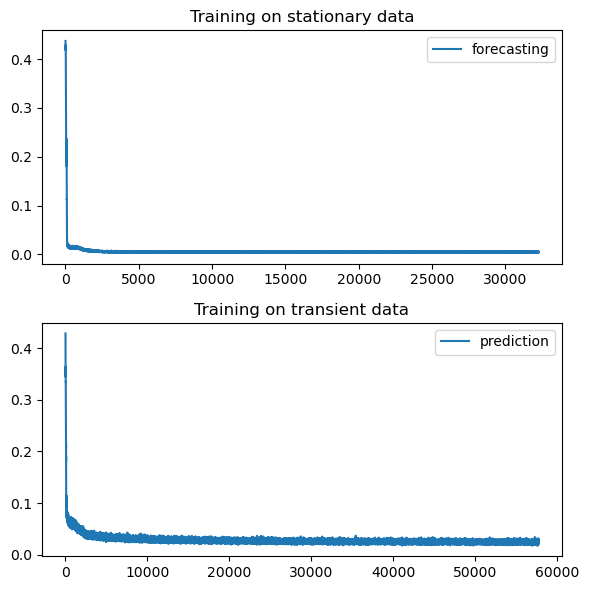

In [5]:
# --! plot training statistics --!

with torch.no_grad():
    loss_stat_mean = loss[0]
    loss_trans     = loss[2]

    plt.figure(figsize=(6, 6))

    plt.subplot(2, 1, 1)
    plt.title('Training on stationary data')
    plt.plot(loss_stat_mean[0], label='forecasting')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.title('Training on transient data')
    plt.plot(loss_trans[0], label='prediction')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [6]:
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=48, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=1152, bias=True)
          (1): Identity()
        )
      )
    )
    (mod_mean): Linear(in_features=12, out_features=12, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=24, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=432, bias=True)
          (1): Identity()
        )
      )
    )
    

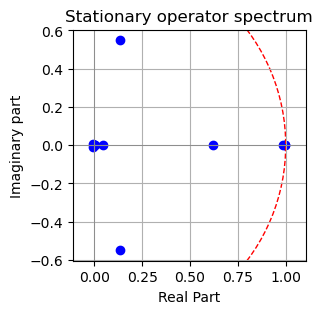

tensor([ 1.3413e-01+0.5488j,  1.3413e-01-0.5488j,  6.2049e-01+0.0000j,
         9.8659e-01+0.0000j,  9.9851e-01+0.0000j,  9.9599e-01+0.0000j,
         4.4287e-02+0.0000j, -6.5978e-03+0.0067j, -6.5978e-03-0.0067j,
         1.5371e-03+0.0000j, -2.5705e-04+0.0000j, -1.4585e-05+0.0000j])


In [7]:
# --! visualize stationary operator eigenvalues --!

with torch.no_grad():
    utils_plot.plot_eigs(model)

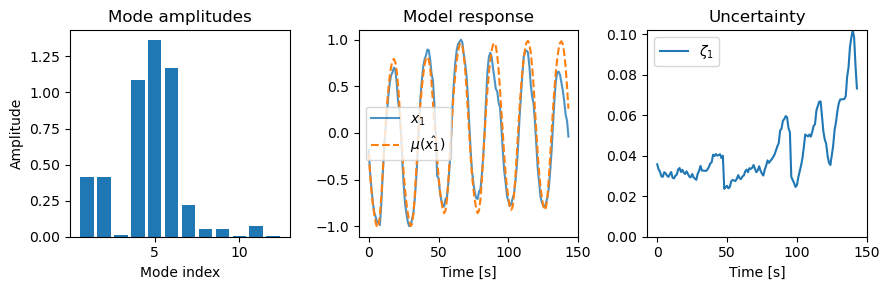

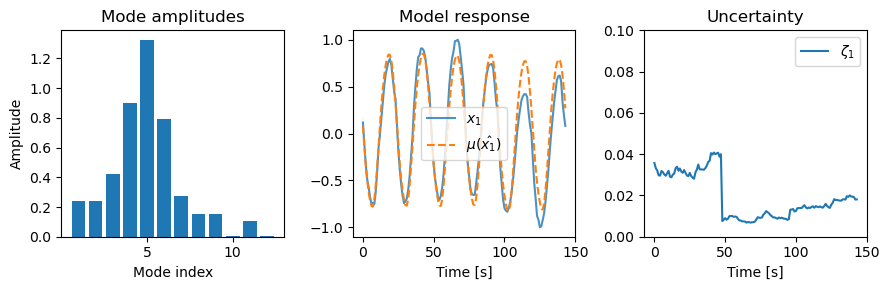

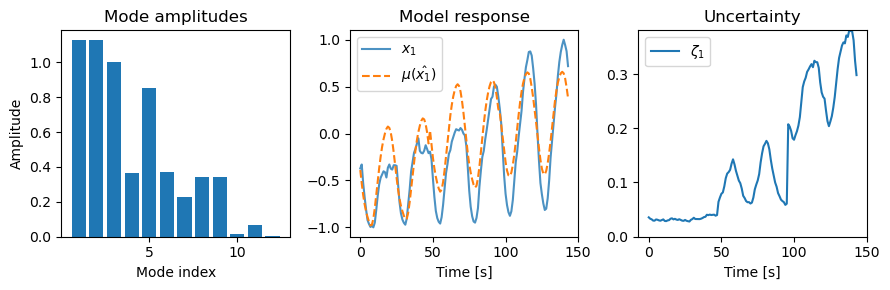

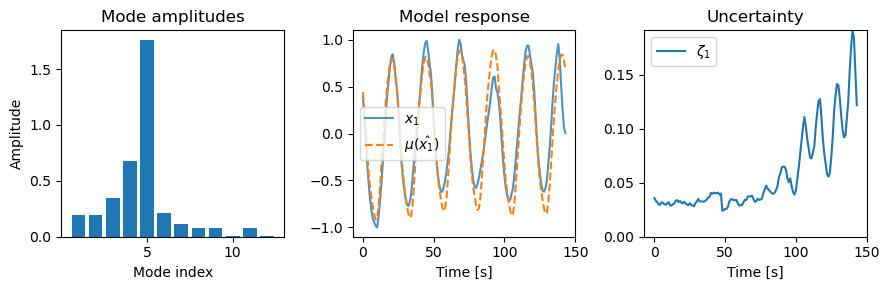

In [8]:
# --! analyze the contribution of stationary operator eigenvalues --!

datadir            = '../../data/baselines/m4_test'
timeseries_nsample = 144

with torch.no_grad():
    for jtimeseries in range(4):
        plot_modes(model, datadir, timeseries_nsample, jtimeseries)

In [9]:
# --! save the trained model --!

modelsaved = True

if modelsaved:
    torch.save(model, '../../models/baselines/m4_h_kind.pt')